# **Heart Disease Prediction**

**Step 1: Import Libraries**

In [18]:
# Data handling libraries
import pandas as pd              # Used to load and manipulate tabular data
import numpy as np               # Used for numerical operations

# Visualization libraries
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns            # For advanced visualization

# Machine learning preprocessing tools
from sklearn.model_selection import train_test_split  # Split dataset into train/test
from sklearn.preprocessing import StandardScaler      # Scale numerical features
from sklearn.preprocessing import OneHotEncoder       # Encode categorical data
from sklearn.compose import ColumnTransformer         # Apply different preprocessing per column
from sklearn.pipeline import Pipeline                 # Create preprocessing pipeline
from sklearn.impute import SimpleImputer              # Handle missing values

**Step 2: Load Dataset**
*   read_csv() → loads dataset into memory
*   head() → shows structure and sample values


**Option A: Upload Dataset Directly to Colab**




In [19]:
# from google.colab import files

# uploaded = files.upload()

In [20]:
import pandas as pd

data = pd.read_csv("Heart_Disease_Prediction.csv")

data.head()

,ID,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,1.0,70,Male,4,130,322,0,2,109,0,2.4,2,3,3,1
1,2.0,67,Female,3,115,564,0,2,160,0,1.6,2,0,7,0
2,3.0,57,Male,2,124,261,0,0,141,0,0.3,1,0,7,1
3,NaN,64,Male,4,128,263,0,0,105,1,0.2,2,1,7,0
4,NaN,74,Female,2,120,269,0,2,121,1,0.2,1,1,3,0


**Option B: Upload Dataset to Google Drive**

In [21]:
# from google.colab import drive
# drive.mount('/content/drive')

In [22]:
# # Load dataset from CSV file
# data = pd.read_csv('/content/Heart_Disease_Prediction.csv')

# # Display first 5 rows
# data.head()

**Step 3: Understand Dataset**
*  info() → data types + missing values
*  describe() → mean, std, min, max
*  isnull().sum() → identifies missing data








In [23]:
# Check dataset information
data.info()

# Statistical summary
data.describe()

# Check missing values
data.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       3 non-null      float64
 1   Age                      270 non-null    int64  
 2   Sex                      270 non-null    str    
 3   Chest pain type          270 non-null    int64  
 4   BP                       270 non-null    int64  
 5   Cholesterol              270 non-null    int64  
 6   FBS over 120             270 non-null    int64  
 7   EKG results              270 non-null    int64  
 8   Max HR                   270 non-null    int64  
 9   Exercise angina          270 non-null    int64  
 10  ST depression            270 non-null    float64
 11  Slope of ST              270 non-null    int64  
 12  Number of vessels fluro  270 non-null    int64  
 13  Thallium                 270 non-null    int64  
 14  Heart Disease            270 non-null

ID                         267
Age                          0
Sex                          0
Chest pain type              0
BP                           0
Cholesterol                  0
FBS over 120                 0
EKG results                  0
Max HR                       0
Exercise angina              0
ST depression                0
Slope of ST                  0
Number of vessels fluro      0
Thallium                     0
Heart Disease                0
dtype: int64

**Step 4: Rename Columns (IMPORTANT for clean coding)**
Your dataset contains spaces in column names → this can cause issues.


*  Makes column names easier to use in code
*  Example: Chest pain type → Chest_pain_type





In [24]:
# Replace spaces with underscore for easier access
data.columns = data.columns.str.replace(' ', '_')

# Check updated column names
data.columns

Index(['ID', 'Age', 'Sex', 'Chest_pain_type', 'BP', 'Cholesterol',
       'FBS_over_120', 'EKG_results', 'Max_HR', 'Exercise_angina',
       'ST_depression', 'Slope_of_ST', 'Number_of_vessels_fluro', 'Thallium',
       'Heart_Disease'],
      dtype='str')

**Step 5: Separate Features and Target**
*  X → all input variables
*  y → prediction target (0 or 1)

In [25]:
# Define input features (X)
X = data.drop('Heart_Disease', axis=1)

# Define target variable (y)
y = data['Heart_Disease']

**Step 6: Train-Test Split (CRITICAL STEP)**

*   Prevents data leakage
*   Model learns only from training data

In [26]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% test data
    random_state=42       # Ensures reproducibility
)

In [27]:
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (216, 14)
Testing features shape: (54, 14)
Training target shape: (216,)
Testing target shape: (54,)


**Step 7: Identify Feature Types**


*  Different preprocessing for different data types
*  In your dataset → most features are numerical

In [28]:
# Select numerical columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Select categorical columns (if any)
categorical_cols = X.select_dtypes(include=['object']).columns

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['ID', 'Age', 'Chest_pain_type', 'BP', 'Cholesterol', 'FBS_over_120',
       'EKG_results', 'Max_HR', 'Exercise_angina', 'ST_depression',
       'Slope_of_ST', 'Number_of_vessels_fluro', 'Thallium'],
      dtype='str')
Categorical Columns: Index(['Sex'], dtype='str')


C:\Users\HP\AppData\Local\Temp\ipykernel_46032\1291705125.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


**Step 8: Create Preprocessing Pipelines**
**8.1 Numerical Pipeline**
*  median → robust for real-world data
*  StandardScaler → ensures equal feature importance





In [29]:
numerical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Fill missing values
    ('scaler', StandardScaler())                   # Normalize data
])

**8.2 Categorical Pipeline (if exists)**

In [30]:
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Fill missing
    ('encoder', OneHotEncoder(handle_unknown='ignore'))    # Convert text to numeric
])

**Step 9: Combine Pipelines**
Applies:
*  Scaling → numerical features
*  Encoding → categorical features





In [31]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

**Step 10: Apply Preprocessing**
*   fit_transform() → learns + applies
*   transform() → applies only
*   Prevents data leakage





In [32]:
# Fit on training data and transform
X_train_processed = preprocessor.fit_transform(X_train)

# Only transform test data (IMPORTANT)
X_test_processed = preprocessor.transform(X_test)

**Step 11: Feature Engineering**
Now we create new meaningful features.
| Feature        | Meaning                                   |
| -------------- | ----------------------------------------- |
| chol_age_ratio | Higher value → higher cardiovascular risk |
| bp_stress      | Measures stress on heart                  |
| high_risk      | Binary classification feature             |


In [33]:
# Create a copy of dataset
X_fe = X.copy()

# Feature 1: Cholesterol to Age Ratio
X_fe['chol_age_ratio'] = X_fe['Cholesterol'] / X_fe['Age']

# Feature 2: Heart Stress Index (Corrected column names)
X_fe['bp_stress'] = X_fe['Max_HR'] - X_fe['BP']

# Feature 3: High Risk Flag
X_fe['high_risk'] = (X_fe['ST_depression'] > 2).astype(int)

# Show first rows
X_fe.head()

,ID,Age,Sex,Chest_pain_type,BP,Cholesterol,FBS_over_120,EKG_results,Max_HR,Exercise_angina,ST_depression,Slope_of_ST,Number_of_vessels_fluro,Thallium,chol_age_ratio,bp_stress,high_risk
0,1.0,70,Male,4,130,322,0,2,109,0,2.4,2,3,3,4.600000,-21,1
1,2.0,67,Female,3,115,564,0,2,160,0,1.6,2,0,7,8.417910,45,0
2,3.0,57,Male,2,124,261,0,0,141,0,0.3,1,0,7,4.578947,17,0
3,NaN,64,Male,4,128,263,0,0,105,1,0.2,2,1,7,4.109375,-23,0
4,NaN,74,Female,2,120,269,0,2,121,1,0.2,1,1,3,3.635135,1,0


**Step 12: Visualization (Understanding Data)**
Helps identify:
*   Skewness
*   Outliers
*   Distribution shape






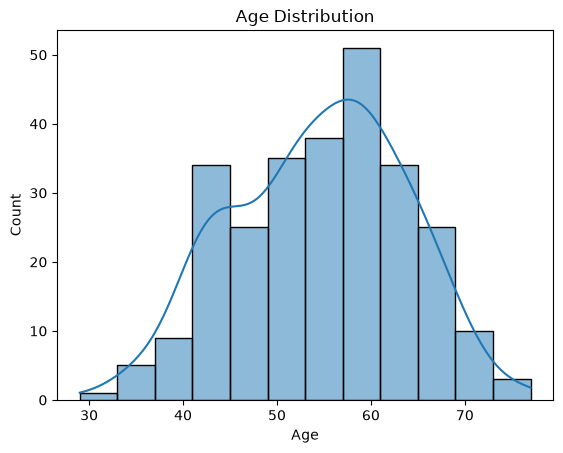

In [34]:
# Plot Age distribution
sns.histplot(data['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

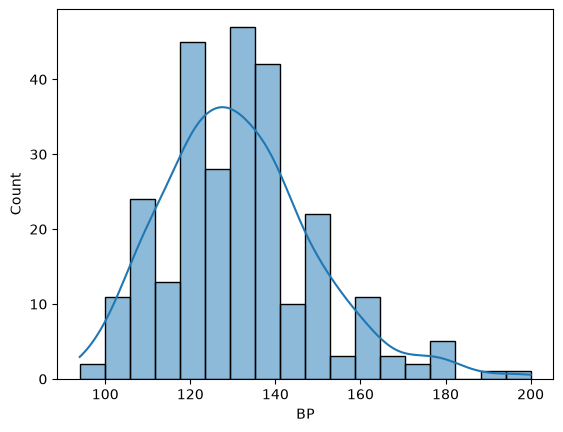

In [35]:
sns.histplot(data['BP'], kde=True)
plt.show()

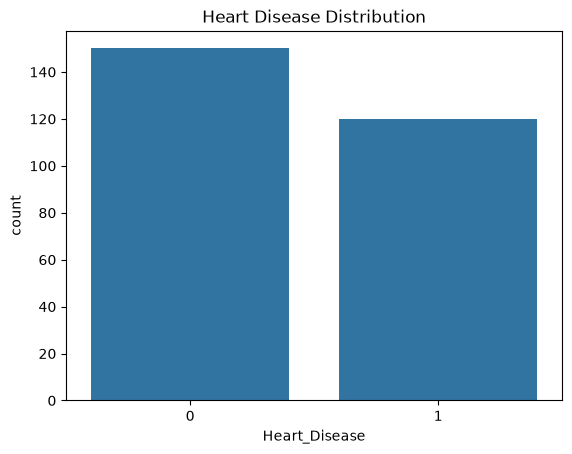

In [36]:
sns.countplot(x="Heart_Disease", data=data)
plt.title("Heart Disease Distribution")
plt.show()

**Step 13: Check Correlation**

*   Shows relationships between variables
*   Helps in feature selection

In [37]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

ValueError: could not convert string to float: 'Male'

<Figure size 1000x800 with 0 Axes>